# Digital Biomarkers Project

The goal of this project is to develop a pipeline for analyzing breast ultrasound images, extracting meaningful features, and classifying tumors into benign or malignant categories. By leveraging medical imaging, feature extraction, and machine learning, the project demonstrates the practical applications of digital biomarkers in personalized healthcare.

Tasks:

- Data Preparation: Organizing ultrasound images and masks for analysis.
- Feature Extraction: Deriving numerical descriptors of tumor properties.
- Classification: Using machine learning to predict tumor type based on extracted features.

## Step 1: Data Preparation
The first step is to prepare a clean, structured dataset of benign and malignant tumor images and segmentation masks.

For this, I download the dataset, try to understand its structure, and preprocessing it for analysis. Using the csv provided, I read the image into four lists: benignant, malignant and the  corresponding segmentation mask, which identifies the tumor's location within the ultrasound image. 
The images are visualized to ensure correctness and alignment between the ultrasound image and its mask.

## Imports

In [1]:
import os
from PIL import Image
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

## Lecture / Demonstration

### Functions
Here I define a function to describe the image we import.

In [2]:
def describe_image(image):
    print("Image dimensions: ", image.shape)
    print("Image type: ", image.dtype)
    print("Image min/max: ", image.min(), image.max())

### Grayscale Image
We load an image of different gray rectangles using plt.imread() and save it into the variable rectangles.

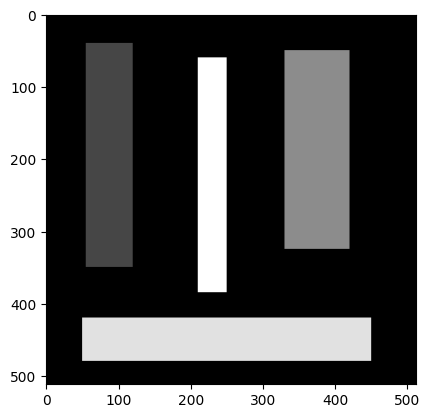

In [3]:
rectangles = plt.imread('rectangles.bmp')

plt.figure()
plt.imshow(rectangles, cmap='gray', vmin=-0, vmax=255) 
plt.show()

- cmap='gray': colormap -> ensures the image is displayed in grayscale
- vmin=0 / vmax=255: set the display range for pixel intensity values

In [13]:
describe_image(rectangles)

Image dimensions:  (512, 512)
Image type:  uint8
Image min/max:  0 255


### Darker Grayscale

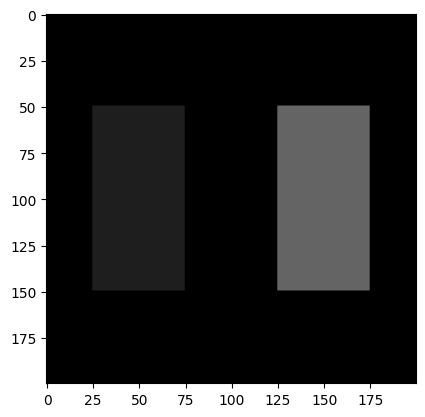

In [6]:
rectangles_darker = plt.imread('rectangles_darker.bmp')

plt.figure()
plt.imshow(rectangles_darker, cmap='gray', vmin=-0, vmax=255) 
plt.show()

In [14]:
describe_image(rectangles_darker)

Image dimensions:  (200, 200)
Image type:  uint8
Image min/max:  0 100


### RGB 

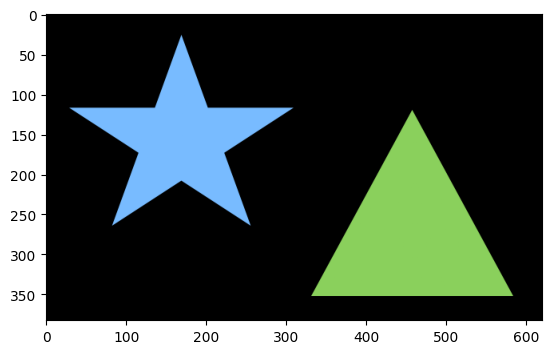

In [9]:
rgb = plt.imread('shapes_RGB.png')

plt.figure()
plt.imshow(rgb) 
plt.show()

In [15]:
describe_image(rgb)

Image dimensions:  (383, 621, 3)
Image type:  float32
Image min/max:  0.0 1.0


Here, we don't need a colormap or a vmin/vmax, because it is an RGB image.

## Project Week 1


### Loading the images
I will perform the following steps to load the images:
1. Paths: Define the paths to the benign, malignant, and normal folders
2. Initialize empty lists to store images and labels
3. Define a function to load the images and labels

#### 1. Paths
In the first step, I save the paths to the folders containing the different datasets to variables so I can use them later on.

In [10]:
base_dir = "../../Breast tumor/Dataset_BUSI_with_GT"
benign_dir = os.path.join(base_dir, "benign")
malignant_dir = os.path.join(base_dir, "malignant")
normal_dir = os.path.join(base_dir, "normal")

#### 2. Initialize empy lists
This is necessary so the images and labels can later on be saved in the lists.

In [3]:
images = [] 
labels = [] 

#### 3. Define a function to load the images and labels


In [28]:
def load_images_from_folder(folder, label):
    for filename in os.listdir(folder):
        # Skip files ending with '_mask.png'

        print(filename)
        if "_mask.png" in filename.lower():
            continue

        file_path = os.path.join(folder, filename)
        try:
            # Open the image, convert to RGB, and resize it to a standard size
            with Image.open(file_path) as img:
                img = img.convert("RGB")  # Ensure 3 color channels
                img = img.resize((224, 224))  # Resize to 224x224 (or your chosen size)
                images.append(np.array(img))  # Convert image to numpy array and store
                labels.append(label)         # Append the label for the image
        except Exception as e:
            print(f"Error loading image {file_path}: {e}")

In [29]:
load_images_from_folder(benign_dir, 1)
load_images_from_folder(malignant_dir, 2)
load_images_from_folder(normal_dir, 0)

benign (246)_mask.png
benign (328).png
benign (282).png
benign (136)_mask.png
benign (300)_mask.png
benign (144).png
benign (87)_mask.png
benign (82).png
benign (185)_mask.png
benign (390).png
benign (34)_mask.png
benign (113).png
benign (406).png
benign (369).png
benign (386).png
benign (20)_mask.png
benign (105).png
benign (228)_mask.png
benign (191)_mask.png
benign (158)_mask.png
benign (410).png
benign (294).png
benign (93)_mask.png
benign (314)_mask.png
benign (408)_mask.png
benign (122)_mask.png
benign (152).png
benign (252)_mask.png
benign (94).png
benign (200).png
benign (345).png
benign (209)_mask.png
benign (179)_mask.png
benign (129).png
benign (386)_mask.png
benign (257).png
benign (312).png
benign (54)_mask_1.png
benign (103)_mask.png
benign (429)_mask.png
benign (191).png
benign (335)_mask.png
benign (273)_mask.png
benign (57).png
benign (267)_mask.png
benign (241).png
benign (321)_mask.png
benign (304).png
benign (117)_mask.png
benign (187).png
benign (41).png
benign (16

In [22]:
print(images[0].shape)

(224, 224, 3)


In [31]:
def load_images_and_masks(data_dir):
    images = []
    masks = []
    
    for file_name in os.listdir(data_dir):
        if file_name.endswith(".png"):
            # Check if it's a mask or an original image
            if '_mask' in file_name:
                # Load mask
                mask_path = os.path.join(data_dir, file_name)
                mask = Image.open(mask_path).convert('L')  # Convert to grayscale
                masks.append((file_name, np.array(mask)))
            else:
                # Load original image
                image_path = os.path.join(data_dir, file_name)
                image = Image.open(image_path).convert('L')  # Convert to grayscale
                images.append((file_name, np.array(image)))

    # Create a paired list of images and masks
    paired_images = []
    paired_masks = []
    for image_name, image in images:
        mask_name = image_name.replace('.png', '_mask.png')
        # Find the corresponding mask
        mask = next((mask for m_name, mask in masks if m_name == mask_name), None)
        paired_images.append(image)
        paired_masks.append(mask)
    
    return paired_images, paired_masks

# Load the images and masks
benign_images, benign_masks = load_images_and_masks(benign_dir)

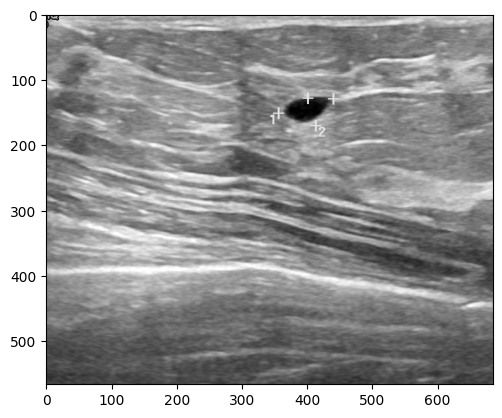

In [34]:
plt.imshow(benign_images[0], cmap='gray') 

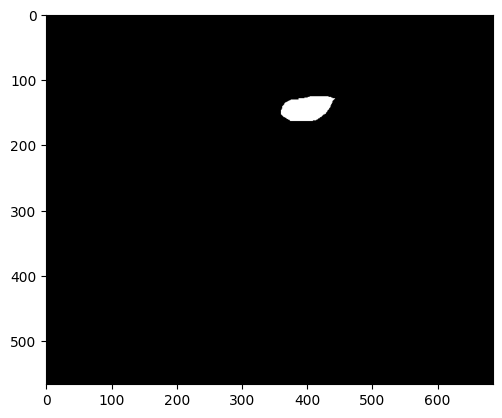

In [33]:
plt.imshow(benign_masks[0], cmap='gray')

# Week 2
Goals:
- Extract features from images

# Week 3
Goals:
- Use different Machine Learning models to classify the tumors
based on the extracted features.